In [1]:
# =========================================
# =========================================

import pandas as pd
import numpy as np

# =========================================
# VISUALIZACIÓN
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# MACHINE LEARNING
# =========================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score
)

# =========================================
# MODELOS BOOSTING
# =========================================

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# =========================================
# REDES NEURONALES
# =========================================

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# =========================================
# SQL SOBRE PANDAS
# =========================================

import duckdb

2026-05-22 18:13:13.582823: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# =========================================
# CARGA DE DATASET
# =========================================

# IMPORTANTE:
# cambiar ruta si es necesario

FILE_PATH = 'sample_trans.csv'


df = pd.read_csv(FILE_PATH)

print(df.shape)

df.head()

(4101885, 8)


,fecha_de_transaccion,canal_de_compra,division,sku_producto,cliente_unico_id,orden_de_venta,monto_bruto,monto_neto
0,7/30/2025 12:00:00 AM,Palacio de Hierro,JUGUETERIA,43828158,19c749a2322a9e0da8f648321c67f773,20250730_1013_342_5857,359.00,359.00
1,11/18/2024 12:00:00 AM,Palacio de Hierro,GOURMET,43814414,c490f3d2f25766657ffb0e756508786e,20241118_1009_421_756,587.00,587.00
2,9/3/2024 12:00:00 AM,E Commerce,DAMAS,43776264,e38923d6ba9d0402b4b0f67c550e54c8,Sites-palacio-MX-Site.5008756547,2190.00,1888.00
3,2/1/2025 12:00:00 AM,E Commerce,TECNOLOGIA,44115898,93ff5ba6316cb5cd8605f56b99c93b01,Sites-palacio-MX-Site.1010194069,13166.37,11350.32
4,12/29/2024 12:00:00 AM,Palacio de Hierro,DAMAS,43825319,3bc936faa076db40a2cbc5d2ffb8861e,20241229_1005_185_6514.0,3114.00,3114.00


In [3]:
# =========================================
# FECHA
# =========================================


df['fecha_de_transaccion'] = pd.to_datetime(
    df['fecha_de_transaccion'],
    errors='coerce'
)

# =========================================
# VARIABLES
# =========================================

cat_cols = [
    'canal_de_compra',
    'division',
    'sku_producto'
]

num_cols = [
    'monto_bruto',
    'monto_neto'
]

# =========================================
# LIMPIEZA DE TEXTO
# =========================================

for col in cat_cols:

    df[col] = df[col].where(
        df[col].isna(),
        df[col]
            .astype(str)
            .str.strip()
            .str.title()
    )

# =========================================
# MISSING EXPLÍCITOS
# =========================================

for col in cat_cols:

    df[col] = df[col].fillna('Missing')

/tmp/ipykernel_7102/18317347.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['fecha_de_transaccion'] = pd.to_datetime(


In [4]:
# =========================================
# REVISIÓN GENERAL
# =========================================

print(df.shape)

print('\nMISSING VALUES\n')

print(df.isnull().sum())

print('\nTIPOS DE DATOS\n')

print(df.dtypes)

(4101885, 8)

MISSING VALUES

fecha_de_transaccion    0
canal_de_compra         0
division                0
sku_producto            0
cliente_unico_id        0
orden_de_venta          0
monto_bruto             0
monto_neto              0
dtype: int64

TIPOS DE DATOS

fecha_de_transaccion    datetime64[ns]
canal_de_compra                 object
division                        object
sku_producto                    object
cliente_unico_id                object
orden_de_venta                  object
monto_bruto                    float64
monto_neto                     float64
dtype: object


In [5]:
query = """

SELECT

    MIN(fecha_de_transaccion) AS fecha_inicial,
    MAX(fecha_de_transaccion) AS fecha_final

FROM df

"""


duckdb.sql(query).df()

,fecha_inicial,fecha_final
0,2024-09-01,2025-08-11


In [6]:
# =========================================
# FECHA DE CORTE
# =========================================

cutoff_date = '2025-05-31'

# =========================================
# HISTÓRICO
# =========================================

hist_df = df[
    df['fecha_de_transaccion'] <= cutoff_date
].copy()

# =========================================
# FUTURO
# =========================================

future_df = df[
    df['fecha_de_transaccion'] > cutoff_date
].copy()

print(hist_df.shape)
print(future_df.shape)

(3450899, 8)
(650986, 8)


In [7]:
clientes_hist = set(
    hist_df['cliente_unico_id'].unique()
)

clientes_future = set(
    future_df['cliente_unico_id'].unique()
)

clientes_check = pd.DataFrame({

    'cliente_unico_id': list(
        clientes_hist.union(clientes_future)
    )
})

clientes_check['en_hist'] = (
    clientes_check['cliente_unico_id']
    .isin(clientes_hist)
    .astype(int)
)

clientes_check['en_future'] = (
    clientes_check['cliente_unico_id']
    .isin(clientes_future)
    .astype(int)
)

clientes_check.groupby([
    'en_hist',
    'en_future'
]).size().reset_index(name='clientes')

,en_hist,en_future,clientes
0,0,1,67727
1,1,0,505062
2,1,1,198152


In [8]:
# =========================================
# TOP 90% DIVISIONES
# =========================================

ventas_division = (

    hist_df

    .groupby('division')['monto_neto']

    .sum()

    .sort_values(
        ascending=False
    )
)

pct_acum = (
    ventas_division.cumsum()
    / ventas_division.sum()
)


top_divisions = pct_acum[
    pct_acum <= 0.90
].index.tolist()

# =========================================
# OTHERS
# =========================================

hist_df['division_grouped'] = np.where(

    hist_df['division'].isin(top_divisions),

    hist_df['division'],

    'Others'
)

In [9]:
# =========================================
# DESCUENTO
# =========================================

hist_df['descuento'] = (
    hist_df['monto_bruto']
    - hist_df['monto_neto']
)

# =========================================
# CLIPS PARA EVITAR
# PROBLEMAS NUMÉRICOS
# =========================================

hist_df['monto_bruto_clip'] = (
    hist_df['monto_bruto']
    .clip(lower=0)
)

hist_df['monto_neto_clip'] = (
    hist_df['monto_neto']
    .clip(lower=0)
)

hist_df['descuento_clip'] = (
    hist_df['descuento']
    .clip(lower=0)
)

In [10]:
features_base = (

    hist_df

    .groupby('cliente_unico_id')

    .agg(

        transacciones_total=(
            'orden_de_venta',
            'count'
        ),

        ordenes_unicas=(
            'orden_de_venta',
            'nunique'
        ),

        skus_distintos=(
            'sku_producto',
            'nunique'
        ),

        ticket_promedio_bruto=(
            'monto_bruto_clip',
            'mean'
        ),

        ticket_promedio_neto=(
            'monto_neto_clip',
            'mean'
        ),

        descuento_promedio=(
            'descuento_clip',
            'mean'
        ),

        monto_bruto_total=(
            'monto_bruto_clip',
            'sum'
        ),

        descuento_total=(
            'descuento_clip',
            'sum'
        ),

        ultima_compra=(
            'fecha_de_transaccion',
            'max'
        )

    )

    .reset_index()
)

In [11]:
max_date = hist_df[
    'fecha_de_transaccion'
].max()

features_base['recency_days'] = (

    max_date

    - features_base['ultima_compra']

).dt.days

In [12]:
windows = [30, 60, 90, 120, 180]

moving_features = []

for window in windows:

    temp = hist_df[

        hist_df['fecha_de_transaccion'] >= (
            pd.to_datetime(cutoff_date)
            - pd.Timedelta(days=window)
        )

    ]

    agg = (

        temp

        .groupby('cliente_unico_id')

        .agg(

            **{

                f'transacciones_{window}d': (
                    'orden_de_venta',
                    'count'
                ),

                f'gasto_{window}d': (
                    'monto_bruto_clip',
                    'sum'
                )
            }
        )

        .reset_index()
    )

    moving_features.append(agg)

# =========================================
# MERGE MOVING FEATURES
# =========================================

moving_df = moving_features[0]

for temp_df in moving_features[1:]:

    moving_df = moving_df.merge(
        temp_df,
        on='cliente_unico_id',
        how='outer'
    )

In [13]:
pivot_division = pd.pivot_table(

    hist_df,

    index='cliente_unico_id',

    columns='division_grouped',

    values='monto_bruto_clip',

    aggfunc='sum',

    fill_value=0
)

pivot_division.columns = [
    f'division_{str(c).lower().replace(" ", "_")}'
    for c in pivot_division.columns
]

pivot_division = pivot_division.reset_index()

In [14]:
pivot_canal = pd.pivot_table(

    hist_df,

    index='cliente_unico_id',

    columns='canal_de_compra',

    values='monto_bruto_clip',

    aggfunc='sum',

    fill_value=0
)

pivot_canal.columns = [
    f'canal_{str(c).lower().replace(" ", "_")}'
    for c in pivot_canal.columns
]

pivot_canal = pivot_canal.reset_index()

In [15]:
# =========================================
# TARGET FUTURO
# =========================================

future_df['monto_neto_clip'] = (
    future_df['monto_neto']
    .clip(lower=0)
)


target_df = (

    future_df

    .groupby('cliente_unico_id')

    .agg(

        target_gasto_2m=(
            'monto_neto_clip',
            'sum'
        )
    )

    .reset_index()
)

In [16]:
final_df = (

    features_base

    .merge(
        moving_df,
        on='cliente_unico_id',
        how='left'
    )

    .merge(
        pivot_division,
        on='cliente_unico_id',
        how='left'
    )

    .merge(
        pivot_canal,
        on='cliente_unico_id',
        how='left'
    )

    .merge(
        target_df,
        on='cliente_unico_id',
        how='left'
    )
)

# =========================================
# MISSING
# =========================================

final_df = final_df.fillna(0)

In [17]:
# =========================================
# VARIABLES TEMPORALES ROBUSTAS
# =========================================

# IMPORTANTE:
# evitamos negativos por devoluciones
# para construir ratios más estables

cols_gasto = [

    'gasto_30d',
    'gasto_60d',
    'gasto_90d',
    'gasto_120d',
    'gasto_180d',

    'monto_bruto_total',
    'descuento_total'
]

for col in cols_gasto:

    final_df[col] = (
        final_df[col]
        .clip(lower=0)
    )

# =========================================
# RATIO GASTO RECIENTE
# =========================================

# captura momentum reciente
# clientes activos recientemente
# tienden a recomprar

final_df['ratio_gasto_reciente'] = (

    final_df['gasto_30d']

    /

    (
        final_df['gasto_180d'] + 1
    )
)

# =========================================
# RATIO FRECUENCIA RECIENTE
# =========================================

final_df['ratio_freq_reciente'] = (

    final_df['transacciones_30d']

    /

    (
        final_df['transacciones_total'] + 1
    )
)

# =========================================
# RATIO DESCUENTO
# =========================================

final_df['ratio_descuento'] = (

    final_df['descuento_total']

    /

    (
        final_df['monto_bruto_total'] + 1
    )
)

# =========================================
# CAPEAR RATIOS EXTREMOS
# =========================================

final_df['ratio_gasto_reciente'] = (
    final_df['ratio_gasto_reciente']
    .clip(0, 100)
)

final_df['ratio_freq_reciente'] = (
    final_df['ratio_freq_reciente']
    .clip(0, 100)
)

final_df['ratio_descuento'] = (
    final_df['ratio_descuento']
    .clip(0, 1)
)

In [18]:
# =========================================
# TARGET POSITIVO
# =========================================

# las devoluciones futuras no representan
# CLV negativo real

final_df['target_gasto_2m'] = (

    final_df['target_gasto_2m']

    .clip(lower=0)
)

# =========================================
# CAP OUTLIERS
# =========================================

# reducimos whales extremos

cap = final_df[
    'target_gasto_2m'
].quantile(0.999)

final_df['target_gasto_2m'] = (

    final_df['target_gasto_2m']

    .clip(upper=cap)
)

# =========================================
# TRANSFORMACIÓN LOG
# =========================================

final_df['target_log'] = np.log1p(
    final_df['target_gasto_2m']
)

In [19]:
# =========================================
# DUPLICADOS
# =========================================

print(
    'Duplicados cliente:',
    final_df['cliente_unico_id']
    .duplicated()
    .sum()
)

# =========================================
# NAN
# =========================================

print(
    'NaN totales:',
    final_df.isna().sum().sum()
)

# =========================================
# INFINITOS
# =========================================

print(
    'Infinitos:',
    np.isinf(
        final_df.select_dtypes(include=np.number)
    ).sum().sum()
)

# =========================================
# TARGET
# =========================================

display(
    final_df['target_gasto_2m']
    .describe()
)

Duplicados cliente: 0
NaN totales: 0
Infinitos: 0


count    703214.000000
mean       1654.418687
std        7128.309569
min           0.000000
25%           0.000000
50%           0.000000
75%         416.507500
max      129300.000000
Name: target_gasto_2m, dtype: float64

In [22]:
X = final_df.drop(columns=[

    'cliente_unico_id',
    'target_gasto_2m',
    'target_log',
    'ultima_compra'

], errors='ignore')

y = final_df['target_log']

In [20]:
# =========================================
# CHURN IMPLÍCITO
# =========================================

# cliente que no compró
# en ventana futura

churn_flag = (
    final_df['target_gasto_2m'] == 0
).astype(int)

print(
    churn_flag.value_counts(normalize=True)
)

target_gasto_2m
1    0.722329
0    0.277671
Name: proportion, dtype: float64


In [23]:
# =========================================
# FORZAR NUMÉRICO
# =========================================

X = X.apply(pd.to_numeric)

# =========================================
# REEMPLAZAR INF
# =========================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# =========================================
# RELLENAR NAN
# =========================================

X = X.fillna(0)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=churn_flag
)

In [25]:
print(
    'Train churn:',
    (np.expm1(y_train) == 0).mean()
)

print(
    'Test churn:',
    (np.expm1(y_test) == 0).mean()
)

Train churn: 0.7223283816620479
Test churn: 0.7223324303378057


In [26]:
def evaluar_modelo(

    model,

    X_train,
    X_test,

    y_train,
    y_test
):

    # =============================
    # TRAIN
    # =============================

    pred_train_log = model.predict(
        X_train
    )

    pred_train = np.expm1(
        pred_train_log
    )

    y_train_real = np.expm1(
        y_train
    )

    pred_train = np.clip(
        pred_train,
        0,
        None
    )

    # =============================
    # TEST
    # =============================

    pred_test_log = model.predict(
        X_test
    )

    pred_test = np.expm1(
        pred_test_log
    )

    y_test_real = np.expm1(
        y_test
    )

    pred_test = np.clip(
        pred_test,
        0,
        None
    )

    # =============================
    # MÉTRICAS
    # =============================

    metricas = pd.DataFrame({

        'Train': [

            mean_absolute_error(
                y_train_real,
                pred_train
            ),

            mean_absolute_percentage_error(
                y_train_real + 1,
                pred_train + 1
            ),

            np.sqrt(
                mean_squared_error(
                    y_train_real,
                    pred_train
                )
            ),

            r2_score(
                y_train_real,
                pred_train
            )

        ],

        'Test': [

            mean_absolute_error(
                y_test_real,
                pred_test
            ),

            mean_absolute_percentage_error(
                y_test_real + 1,
                pred_test + 1
            ),

            np.sqrt(
                mean_squared_error(
                    y_test_real,
                    pred_test
                )
            ),

            r2_score(
                y_test_real,
                pred_test
            )

        ]

    },

    index=[

        'MAE',
        'MAPE',
        'RMSE',
        'R2'

    ])

    return metricas.round(4)

In [27]:
# =========================================
# LIGHTGBM
# =========================================

lgbm = LGBMRegressor(

    # tipo problema
    objective='regression',

    # árboles
    n_estimators=1500,

    # velocidad aprendizaje
    learning_rate=0.01,

    # profundidad máxima
    max_depth=8,

    # hojas máximas
    num_leaves=63,

    # filas aleatorias
    subsample=0.8,

    # columnas aleatorias
    colsample_bytree=0.8,

    # regularización
    reg_alpha=2,
    reg_lambda=2,

    # observaciones mínimas hoja
    min_child_samples=50,

    # reproducibilidad
    random_state=42,

    # cpu
    n_jobs=-1,

    # quitar warnings
    verbosity=-1
)

# =========================================
# ENTRENAMIENTO
# =========================================

lgbm.fit(

    X_train,
    y_train
)

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,8
,learning_rate,0.01
,n_estimators,1500
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [28]:
metricas_lgbm = evaluar_modelo(

    lgbm,

    X_train,
    X_test,

    y_train,
    y_test
)

metricas_lgbm

,Train,Test
MAE,1587.0472,1589.8622
MAPE,13.3923,17.8269
RMSE,6974.2774,6921.4396
R2,0.0491,0.0314


In [29]:
feature_importance_lgbm = pd.DataFrame({

    'feature': X_train.columns,

    'importance': lgbm.feature_importances_

})

feature_importance_lgbm = (

    feature_importance_lgbm

    .sort_values(
        'importance',
        ascending=False
    )
)

feature_importance_lgbm.head(20)

,feature,importance
8,recency_days,6738
22,division_damas,3645
35,canal_palacio_de_hierro,3476
25,division_others,3396
20,division_boutiques,3239
18,gasto_180d,3137
27,division_tecnologia,3019
21,division_caballeros,3012
19,division_belleza,2945
24,division_lujo_moda,2821


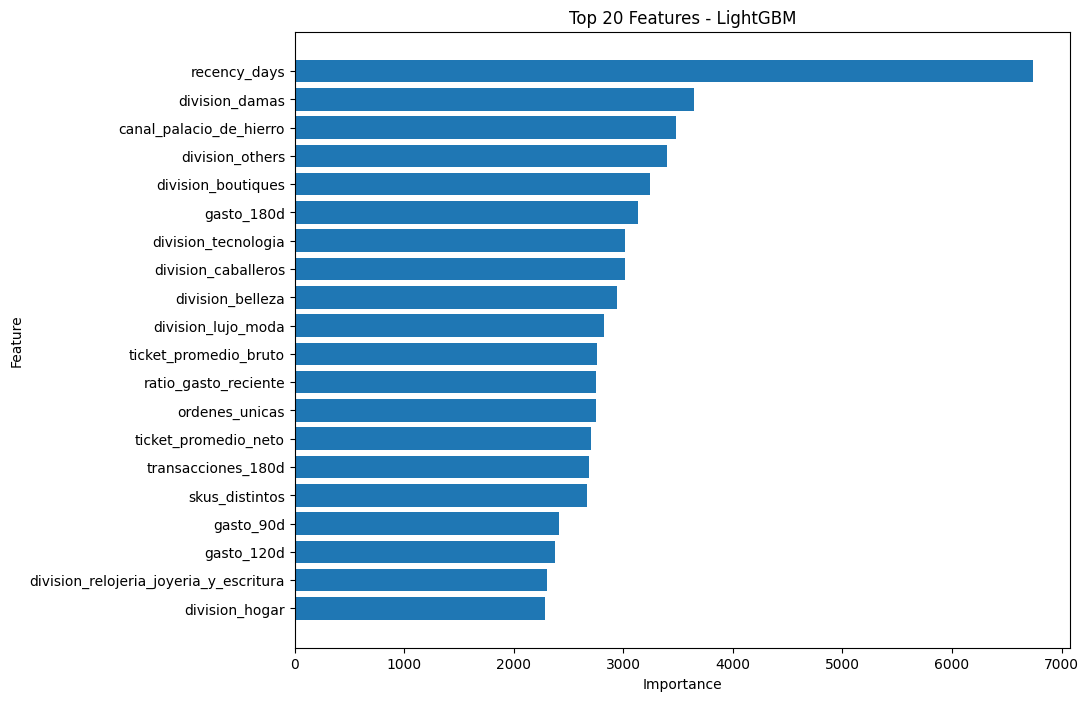

In [30]:
plt.figure(figsize=(10,8))

top_features = (

    feature_importance_lgbm

    .head(20)

    .sort_values('importance')
)

plt.barh(

    top_features['feature'],

    top_features['importance']
)

plt.title(
    'Top 20 Features - LightGBM'
)

plt.xlabel('Importance')

plt.ylabel('Feature')

plt.show()

In [31]:
# =========================================
# XGBOOST
# =========================================

xgb = XGBRegressor(

    objective='reg:squarederror',

    n_estimators=1200,

    learning_rate=0.01,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=2,

    reg_lambda=2,

    min_child_weight=10,

    gamma=1,

    random_state=42,

    n_jobs=-1
)

# =========================================
# ENTRENAMIENTO
# =========================================

xgb.fit(

    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
metricas_xgb = evaluar_modelo(

    xgb,

    X_train,
    X_test,

    y_train,
    y_test
)

metricas_xgb

,Train,Test
MAE,1572.4787,1589.1753
MAPE,11.4119,18.3642
RMSE,6899.9744,6913.9550
R2,0.0692,0.0335


In [33]:
feature_importance_xgb = pd.DataFrame({

    'feature': X_train.columns,

    'importance': xgb.feature_importances_

})

feature_importance_xgb = (

    feature_importance_xgb

    .sort_values(
        'importance',
        ascending=False
    )
)

feature_importance_xgb.head(20)

,feature,importance
1,ordenes_unicas,0.517532
2,skus_distintos,0.132452
0,transacciones_total,0.060204
8,recency_days,0.022288
31,canal_e_commerce,0.019766
15,transacciones_120d,0.017204
35,canal_palacio_de_hierro,0.014184
17,transacciones_180d,0.011962
38,ratio_descuento,0.009278
11,transacciones_60d,0.008714


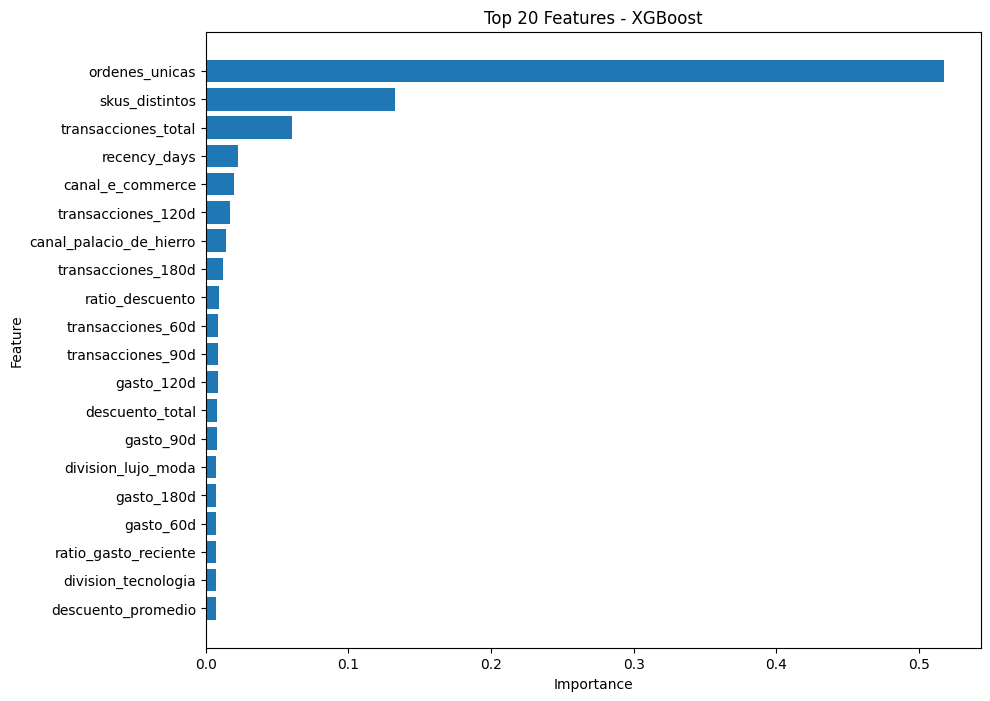

In [34]:
plt.figure(figsize=(10,8))

top_features = (

    feature_importance_xgb

    .head(20)

    .sort_values('importance')
)

plt.barh(

    top_features['feature'],

    top_features['importance']
)

plt.title(
    'Top 20 Features - XGBoost'
)

plt.xlabel('Importance')

plt.ylabel('Feature')

plt.show()

# Neural network

In [48]:
# =========================================
# TARGET REAL PARA NN
# =========================================

y_nn = final_df['target_gasto_2m']

# =========================================
# SPLIT NN
# =========================================

X_train_nn_df, X_test_nn_df, y_train_nn, y_test_nn = train_test_split(

    X,

    y_nn,

    test_size=0.20,

    random_state=42,

    stratify=churn_flag
)

In [56]:
# =========================================
# SCALING RED NEURONAL
# =========================================

from sklearn.preprocessing import StandardScaler

scaler_nn = StandardScaler()

X_train_nn = scaler_nn.fit_transform(
    X_train_nn_df
)

X_test_nn = scaler_nn.transform(
    X_test_nn_df
)

In [57]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Dense,
    Dropout,
    BatchNormalization

)

from tensorflow.keras.regularizers import l2

# =========================================
# RED PROFUNDA
# =========================================

nn_model = Sequential()

# =========================================
# BLOQUE 1
# =========================================

nn_model.add(

    Dense(

        512,

        activation='relu',

        kernel_regularizer=l2(1e-4),

        input_shape=(
            X_train_nn.shape[1],
        )
    )
)

nn_model.add(
    BatchNormalization()
)

nn_model.add(
    Dropout(0.35)
)

# =========================================
# BLOQUE 2
# =========================================

nn_model.add(

    Dense(

        256,

        activation='relu',

        kernel_regularizer=l2(1e-4)
    )
)

nn_model.add(
    BatchNormalization()
)

nn_model.add(
    Dropout(0.30)
)

# =========================================
# BLOQUE 3
# =========================================

nn_model.add(

    Dense(

        128,

        activation='relu',

        kernel_regularizer=l2(1e-4)
    )
)

nn_model.add(
    BatchNormalization()
)

nn_model.add(
    Dropout(0.25)
)

# =========================================
# BLOQUE 4
# =========================================

nn_model.add(

    Dense(

        64,

        activation='relu',

        kernel_regularizer=l2(1e-4)
    )
)

nn_model.add(
    BatchNormalization()
)

nn_model.add(
    Dropout(0.20)
)

# =========================================
# BLOQUE 5
# =========================================

nn_model.add(

    Dense(

        32,

        activation='relu',

        kernel_regularizer=l2(1e-4)
    )
)

# =========================================
# BLOQUE 6
# =========================================

nn_model.add(

    Dense(

        16,

        activation='relu'
    )
)

# =========================================
# SALIDA
# =========================================

nn_model.add(

    Dense(

        1,

        activation='relu'
    )
)

nn_model.summary()

/home/david-diaz/ds-venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 512)            │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,425 (779.00 KB)

 Trainable params: 197,505 (771.50 KB)

 Non-trainable params: 1,920 (7.50 KB)

In [58]:
optimizer = tf.keras.optimizers.Adam(

    learning_rate=0.0003,

    clipnorm=1.0
)

In [59]:
nn_model.compile(

    optimizer=optimizer,

    loss=tf.keras.losses.Huber(

        delta=1000
    ),

    metrics=[

        'mae',

        tf.keras.metrics.RootMeanSquaredError()
    ]
)

In [60]:
from tensorflow.keras.callbacks import (

    EarlyStopping,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=15,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=5,

    min_lr=1e-6
)

In [61]:
history = nn_model.fit(

    X_train_nn,

    y_train_nn,

    validation_data=(

        X_test_nn,
        y_test_nn
    ),

    epochs=150,

    batch_size=1024,

    callbacks=[

        early_stop,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/150
550/550 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - loss: 1505851.5000 - mae: 1653.4994 - root_mean_squared_error: 7311.0239 - val_loss: 1464421.2500 - val_mae: 1646.8882 - val_root_mean_squared_error: 7147.6714 - learning_rate: 3.0000e-04
Epoch 2/150
550/550 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - loss: 1436778.7500 - mae: 1661.9716 - root_mean_squared_error: 7126.4834 - val_loss: 1438232.6250 - val_mae: 1683.9590 - val_root_mean_squared_error: 7074.6914 - learning_rate: 3.0000e-04
Epoch 3/150
550/550 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - loss: 1416805.6250 - mae: 1664.5626 - root_mean_squared_error: 6979.2988 - val_loss: 1435534.7500 - val_mae: 1678.5052 - val_root_mean_squared_error: 7047.5322 - learning_rate: 3.0000e-04
Epoch 4/150
550/550 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - loss: 1412062.8750 - mae: 1664.2657 - root_mean_squared_error: 6918.4097 - val_loss: 1404818.2500 - val_mae: 1656.4388 - val_root_mean_squared_error: 6867.0835 - learning_rate: 3.0000e-04
Epoch 5/150
550/550 

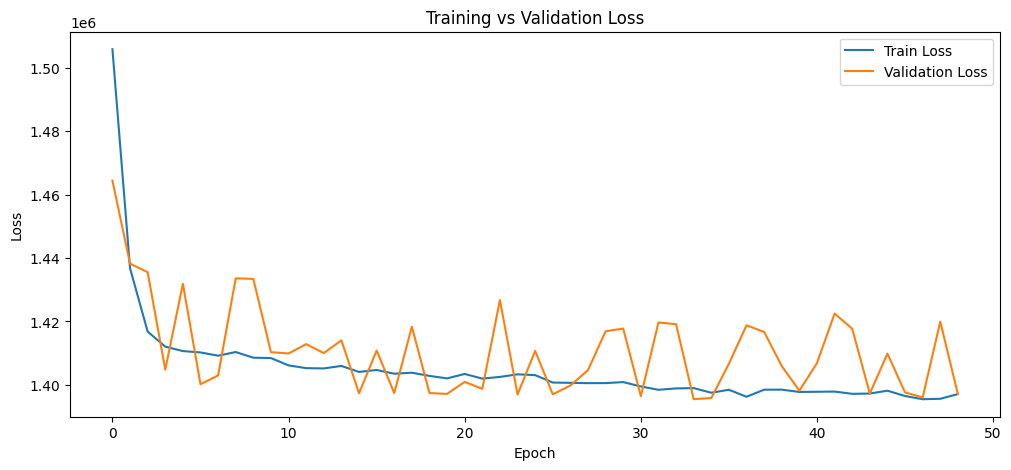

In [62]:
plt.figure(figsize=(12,5))

plt.plot(

    history.history['loss'],

    label='Train Loss'
)

plt.plot(

    history.history['val_loss'],

    label='Validation Loss'
)

plt.title(
    'Training vs Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

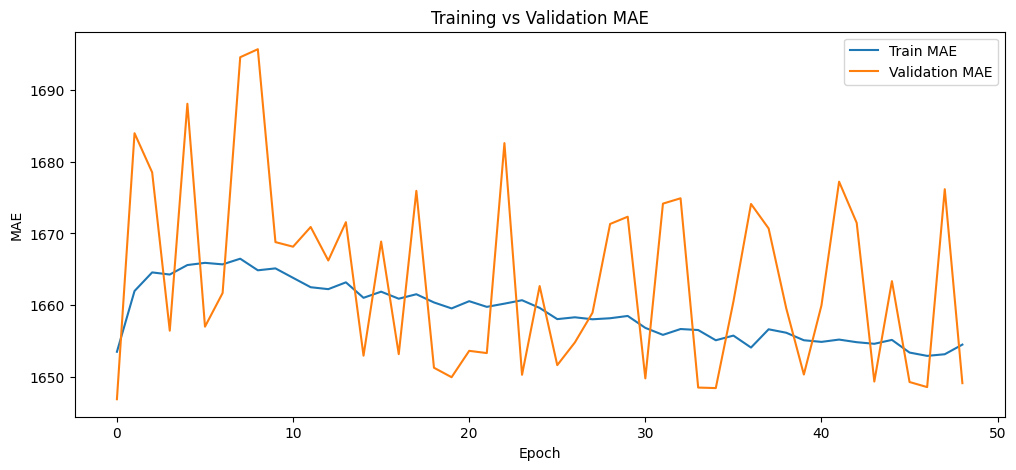

In [63]:
plt.figure(figsize=(12,5))

plt.plot(

    history.history['mae'],

    label='Train MAE'
)

plt.plot(

    history.history['val_mae'],

    label='Validation MAE'
)

plt.title(
    'Training vs Validation MAE'
)

plt.xlabel('Epoch')

plt.ylabel('MAE')

plt.legend()

plt.show()

In [64]:
pred_train_nn = nn_model.predict(
    X_train_nn
).flatten()

pred_test_nn = nn_model.predict(
    X_test_nn
).flatten()

# =========================================
# EVITAR NEGATIVOS
# =========================================

pred_train_nn = np.clip(
    pred_train_nn,
    0,
    None
)

pred_test_nn = np.clip(
    pred_test_nn,
    0,
    None
)

17581/17581 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step
4396/4396 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


In [65]:
metricas_nn = pd.DataFrame({

    'Train': [

        mean_absolute_error(
            y_train_nn,
            pred_train_nn
        ),

        mean_absolute_percentage_error(
            y_train_nn + 1,
            pred_train_nn + 1
        ),

        np.sqrt(
            mean_squared_error(
                y_train_nn,
                pred_train_nn
            )
        ),

        r2_score(
            y_train_nn,
            pred_train_nn
        )
    ],

    'Test': [

        mean_absolute_error(
            y_test_nn,
            pred_test_nn
        ),

        mean_absolute_percentage_error(
            y_test_nn + 1,
            pred_test_nn + 1
        ),

        np.sqrt(
            mean_squared_error(
                y_test_nn,
                pred_test_nn
            )
        ),

        r2_score(
            y_test_nn,
            pred_test_nn
        )
    ]

},

index=[

    'MAE',
    'MAPE',
    'RMSE',
    'R2'
])

metricas_nn.round(4)

,Train,Test
MAE,1658.7175,1648.5123
MAPE,182.0937,185.2530
RMSE,10309.2684,6918.5331
R2,-1.0778,0.0322


In [69]:
comparacion_modelos = pd.concat({

    'LightGBM': metricas_lgbm,

    'XGBoost': metricas_xgb,

    'NeuralNet': metricas_nn

},

axis=1)

# =========================================
# QUITAR R2
# =========================================

comparacion_modelos = comparacion_modelos.drop(
    index='R2'
)

# =========================================
# FORMATO MONEDA
# =========================================

comparacion_modelos = comparacion_modelos.applymap(

    lambda x: f'${x:,.2f}'
)

comparacion_modelos

/tmp/ipykernel_7102/4082156017.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  comparacion_modelos = comparacion_modelos.applymap(


LightGBM               XGBoost              NeuralNet           
          Train       Test      Train       Test       Train       Test
MAE   $1,587.05  $1,589.86  $1,572.48  $1,589.18   $1,658.72  $1,648.51
MAPE     $13.39     $17.83     $11.41     $18.36     $182.09    $185.25
RMSE  $6,974.28  $6,921.44  $6,899.97  $6,913.95  $10,309.27  $6,918.53